In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from nn import DeepNN
from utils import relu, relu_backward, softmax, categorical_crossentropy, sigmoid, binary_crossentropy, one_hot_encode

### Binary Classification

Epoch 0 | Loss: 0.6908
Epoch 200 | Loss: 0.2794
Epoch 400 | Loss: 0.2606
Epoch 600 | Loss: 0.2544
Epoch 800 | Loss: 0.2523
Epoch 1000 | Loss: 0.2510
Epoch 1200 | Loss: 0.2503
Epoch 1400 | Loss: 0.2498
Final Binary Accuracy: 88.30%



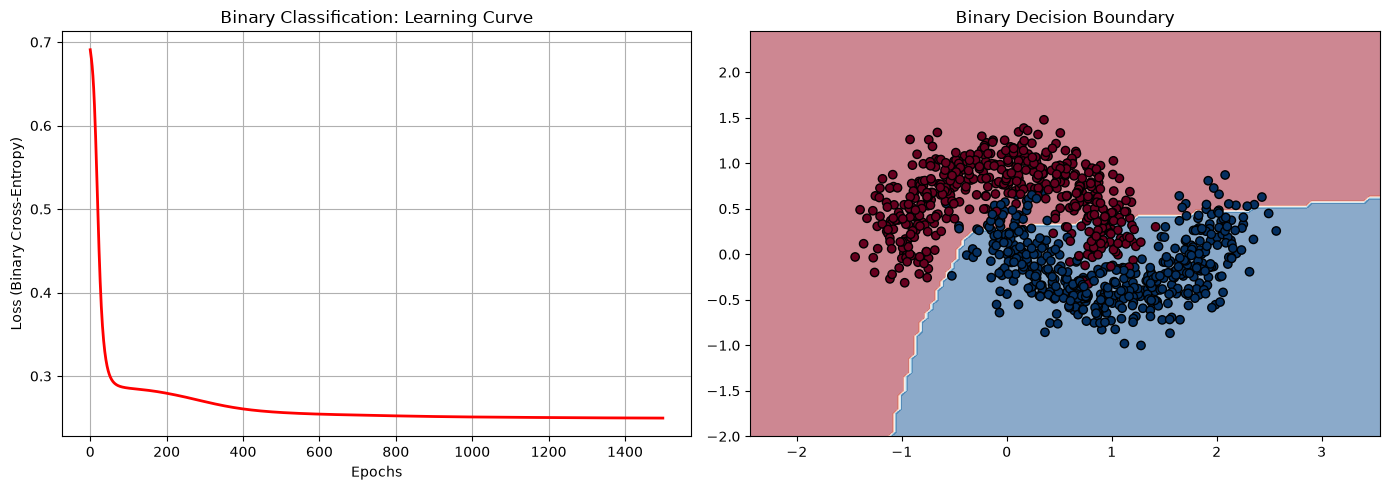

In [2]:
# Binary Dataset
X_bin_data, Y_bin_data = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_bin = X_bin_data.T
Y_bin = Y_bin_data.reshape(1, -1) # Shape: (1, 1000)

# Binary DNN
model_bin = DeepNN(layer_dims=[2, 10, 1], 
                   mid_activation=relu, 
                   mid_activation_backward=relu_backward,
                   out_activation=sigmoid)

# Training
epochs_bin = 1500
learning_rate_bin = 0.5
losses_bin = []

for epoch in range(epochs_bin):
    A, caches = model_bin.forward_propagation(X_bin)
    loss = binary_crossentropy(Y_bin, A)
    grads = model_bin.backward_propagation(X_bin, Y_bin, caches)
    model_bin.update_parameters(grads, learning_rate_bin)
    
    losses_bin.append(loss)
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# Testing
predictions_bin = (model_bin.predict(X_bin) > 0.5).astype(int)
accuracy_bin = np.mean(predictions_bin == Y_bin)
print(f"Final Binary Accuracy: {accuracy_bin * 100:.2f}%\n")

# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_bin, color='red', linewidth=2)
plt.title("Binary Classification: Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.grid(True)

plt.subplot(1, 2, 2)
x_min, x_max = X_bin[0, :].min() - 1, X_bin[0, :].max() + 1
y_min, y_max = X_bin[1, :].min() - 1, X_bin[1, :].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

grid = np.c_[xx.ravel(), yy.ravel()].T
Z = model_bin.predict(grid)
Z = (Z > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='RdBu')
plt.scatter(X_bin[0, :], X_bin[1, :], c=Y_bin[0, :], edgecolors='k', cmap='RdBu')
plt.title("Binary Decision Boundary")

plt.tight_layout()
plt.show()

### Multiclass Classification

Epoch 0 | Loss: 1.0870
Epoch 200 | Loss: 0.0021
Epoch 400 | Loss: 0.0010
Epoch 600 | Loss: 0.0006
Epoch 800 | Loss: 0.0005
Epoch 1000 | Loss: 0.0004
Epoch 1200 | Loss: 0.0003
Epoch 1400 | Loss: 0.0003
Final Multi-class Accuracy: 100.00%



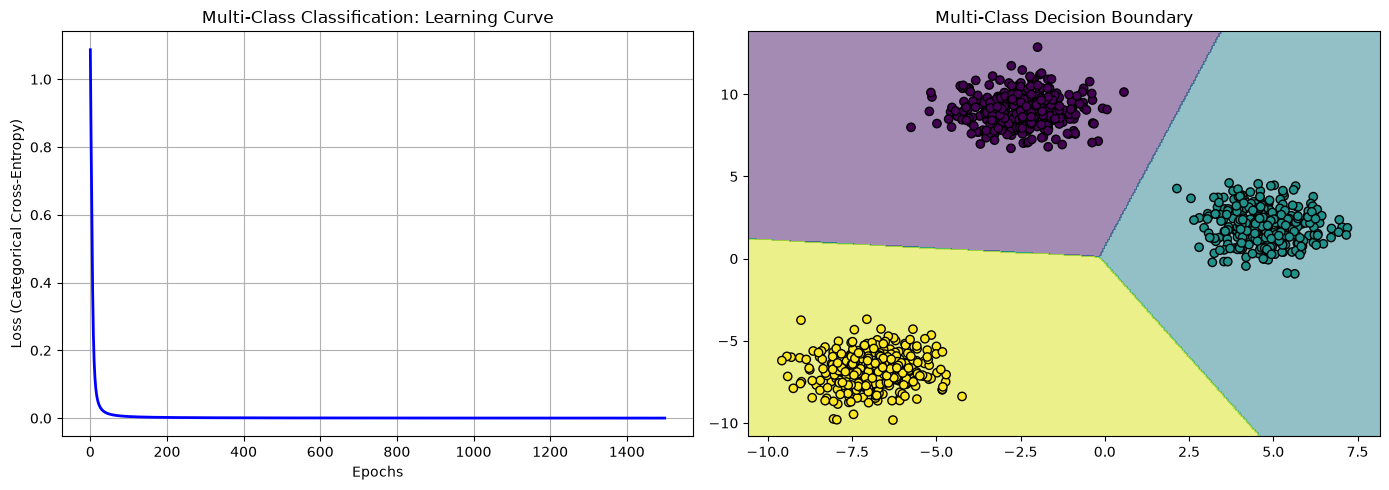

In [3]:
# Multi-class Dataset
X_multi_data, Y_multi_data = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)
X_multi = X_multi_data.T
Y_multi = one_hot_encode(Y_multi_data, num_classes=3)

# Multi-class DNN
model_multi = DeepNN(layer_dims=[2, 15, 3], 
                     mid_activation=relu, 
                     mid_activation_backward=relu_backward,
                     out_activation=softmax)

# Training
epochs_multi = 1500
learning_rate_multi = 0.1
losses_multi = []

for epoch in range(epochs_multi):
    A, caches = model_multi.forward_propagation(X_multi)
    loss = categorical_crossentropy(Y_multi, A)
    grads = model_multi.backward_propagation(X_multi, Y_multi, caches)
    model_multi.update_parameters(grads, learning_rate_multi)
    
    losses_multi.append(loss)
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# Testing
predictions_multi = np.argmax(model_multi.predict(X_multi), axis=0)
accuracy_multi = np.mean(predictions_multi == Y_multi_data)
print(f"Final Multi-class Accuracy: {accuracy_multi * 100:.2f}%\n")

# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_multi, color='blue', linewidth=2)
plt.title("Multi-Class Classification: Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (Categorical Cross-Entropy)")
plt.grid(True)

plt.subplot(1, 2, 2)
x_min, x_max = X_multi[0, :].min() - 1, X_multi[0, :].max() + 1
y_min, y_max = X_multi[1, :].min() - 1, X_multi[1, :].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

grid = np.c_[xx.ravel(), yy.ravel()].T
Z = model_multi.predict(grid)
Z = np.argmax(Z, axis=0).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X_multi[0, :], X_multi[1, :], c=Y_multi_data, edgecolors='k', cmap='viridis')
plt.title("Multi-Class Decision Boundary")

plt.tight_layout()
plt.show()